# Notebook 3: Frequency-Dependent Power Dynamics — Sine Wave Emergence

This notebook explores an unexpected phenomenon in the **arithmetic square wave** workload:
as the hot/cold cycle frequency increases, the square-wave power signature gradually morphs
into a **sine wave**.  This reveals that the GPU power control system acts as a **first-order
low-pass filter** with a measurable −3 dB bandwidth.

For every experiment discovered under `square-wave-traces/`, the notebook:

1. Loads all cycle-count variants and derives instantaneous power from energy counters
2. Shows the time-domain power evolution from low-frequency (clean square wave) to
   high-frequency (attenuated sine wave)
3. Computes the amplitude spectrum and plots a composite **Bode diagram**
4. Fits a first-order low-pass model and reports the corner frequency τ
5. Displays phase-folded average cycle shapes across the sweep


In [46]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import AutoMinorLocator
from matplotlib.colors import LogNorm
from pathlib import Path
from scipy import signal, optimize, stats
from scipy.stats import binned_statistic
from scipy.optimize import minimize_scalar, curve_fit

from ampere import (
    Ensemble, Metric, MetricConfig, MetricType,
    connect, set_backend, ak,
)

set_backend('pandas')
connect(server="localhost", port=5555)

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'mathtext.fontset': 'dejavuserif',
    'font.size': 9.5,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 8.5,
    'ytick.labelsize': 8.5,
    'legend.fontsize': 8.5,
    'figure.titlesize': 13,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.6,
    'grid.linewidth': 0.4,
    'lines.linewidth': 1.0,
})
BG = '#fafafa'

TDP         = 560           # W, MI300A / MI250X per device
GPU_DEVICES = (0, 2, 4, 6)
TDP_TOTAL   = TDP * len(GPU_DEVICES)


Pandas backend active — skipping Arkouda connection.


## 1. Data Discovery

Scan `square-wave-traces/` for every device-type directory and every timestamped experiment within it.  New experiments are picked up automatically.

In [47]:
SQ_TRACES_ROOT = Path("./square-wave-traces")

def discover_sw_experiments(root: Path) -> dict:
    """Return nested dict: {experiment_key: {device, exp_dir, cycle_dirs, cycle_counts}}."""
    found = {}
    if not root.exists():
        print(f"[warn] {root} not found")
        return found
    for device_dir in sorted(root.iterdir()):
        if not device_dir.is_dir(): continue
        for exp_dir in sorted(device_dir.iterdir()):
            if not exp_dir.is_dir(): continue
            cycles = sorted(
                [d for d in exp_dir.iterdir()
                 if d.is_dir() and d.name.startswith('cycles-')],
                key=lambda d: int(d.name.rsplit('-', 1)[-1])
            )
            if not cycles: continue
            key = f"{device_dir.name} / {exp_dir.name}"
            found[key] = {
                'device':       device_dir.name,
                'exp_dir':      exp_dir,
                'cycle_dirs':   cycles,
                'cycle_counts': [int(d.name.rsplit('-', 1)[-1]) for d in cycles],
            }
    for key, info in found.items():
        print(f"  {key}: {len(info['cycle_dirs'])} cycle variants  "
              f"({min(info['cycle_counts'])} – {max(info['cycle_counts'])})")
    print(f"\nTotal experiments: {len(found)}")
    return found

SW_EXPERIMENTS = discover_sw_experiments(SQ_TRACES_ROOT)


  MI250X-dgemm-and-HPL-panel / arithmetic-square-wave-04-29-26-13:50:09: 32 cycle variants  (1 – 5040)

Total experiments: 1


## 2. Load Power Data

Derive instantaneous power from cumulative energy counters, combine across devices, and store one time-series per (experiment, cycle-count).

In [48]:
def differentiate_energy(energy_metric):
    t, e = energy_metric.times, energy_metric.values
    dt = t[1:] - t[:-1]
    de = e[1:] - e[:-1]
    p  = de / dt
    p  = ak.where((p < 0) | (dt <= 0), 0.0, p)
    return Metric("power", t[1:], p, MetricConfig(MetricType.INSTANTANEOUS))

def sum_power(*metrics):
    L      = min(len(m.times) for m in metrics)
    times  = min((m.times for m in metrics), key=len)
    values = np.sum([np.asarray(m.values)[:L] for m in metrics], axis=0)
    return Metric('combined_gpu_power', times, values,
                  MetricConfig(MetricType.INSTANTANEOUS))

configs = {
    re.compile(r".*rocm.*energy.*"): MetricConfig(MetricType.CUMULATIVE, scale_factor=1e-6),
    re.compile(r".*amd.*energy.*"): MetricConfig(MetricType.CUMULATIVE, scale_factor=1e-6),
}

def load_experiment(info: dict) -> dict:
    """Load all cycles in one experiment; return {cycle_count: (times, power)}."""
    cycle_dirs  = info['cycle_dirs']
    cycle_counts = info['cycle_counts']

    # Convert any missing CSVs from OTF2
    for d in cycle_dirs:
        if not list(d.glob("*.csv")) and (d / "traces.otf2").exists():
            print(f"  Converting OTF2: {d.name} ...")
            os.system(f'cd "{d}" && ~/otf2csv ./traces.otf2')

    node_ranks = {"Node0": ["Process"]}
    ens = Ensemble.from_trace_paths(
        [str(d) for d in cycle_dirs], node_ranks, configs
    )

    for d in GPU_DEVICES:
        ens.add_derived_metric(
            f"A2rocm_smi:::inst_power:device={d}",
            differentiate_energy,
            f"A2rocm_smi:::energy_count:device={d}",
        )
    ens.add_derived_metric(
        "A2rocm_smi:::combined_gpu_power",
        sum_power,
        *(f"A2rocm_smi:::inst_power:device={d}" for d in GPU_DEVICES),
    )

    result = {}
    for i, run in enumerate(ens.runs):
        try:
            m = run.nodes[0].metrics["A2rocm_smi:::inst_power:device=6"]
            result[cycle_counts[i]] = (np.asarray(m.times), np.asarray(m.values))
        except KeyError:
            print(f"  [warn] no combined power for cycle {cycle_counts[i]}")
    return result

exp_power = {}
for exp_key, info in SW_EXPERIMENTS.items():
    print(f"\nLoading: {exp_key}")
    exp_power[exp_key] = load_experiment(info)
    print(f"  Loaded {len(exp_power[exp_key])} runs")



Loading: MI250X-dgemm-and-HPL-panel / arithmetic-square-wave-04-29-26-13:50:09


Loading Runs: 100%|██████████| 32/32 [00:00<00:00, 51.92it/s]

Deriving metric 'A2rocm_smi:::inst_power:device=0'...
Deriving metric 'A2rocm_smi:::inst_power:device=2'...
Deriving metric 'A2rocm_smi:::inst_power:device=4'...
Deriving metric 'A2rocm_smi:::inst_power:device=6'...
Deriving metric 'A2rocm_smi:::combined_gpu_power'...
  Loaded 32 runs


## Helper Functions

In [49]:
def f0_of(t: np.ndarray, n_cycles: int) -> float:
    return n_cycles / (t[-1] - t[0])

def half_period_ms(t: np.ndarray, n_cycles: int) -> float:
    return 1000.0 * (t[-1] - t[0]) / (2 * n_cycles)

def amplitude_spectrum(t, p, t_skip_head=3.0, t_skip_tail=1.0, fs_max=500.0, dt=None):
    t, p = np.asarray(t, float), np.asarray(p, float)
    mask = (t >= t[0] + t_skip_head) & (t <= t[-1] - t_skip_tail)
    t, p = t[mask], p[mask]
    if len(t) < 64:
        return np.array([]), np.array([])
    if dt is None:
        dt = np.median(np.diff(t))
    fs  = min(1.0 / dt, fs_max)
    tu  = np.arange(t[0], t[-1], 1.0 / fs)
    pu  = np.interp(tu, t, p)
    pd  = signal.detrend(pu, type='linear')
    w   = signal.windows.hann(len(pd))
    spec = np.fft.rfft(pd * w)
    freq = np.fft.rfftfreq(len(pd), 1.0 / fs)
    mag  = (2.0 / w.sum()) * np.abs(spec)
    return freq, mag

def square_wave_amplitude(t, p, t_skip_head=3.0, t_skip_tail=1.0):
    t, p = np.asarray(t, float), np.asarray(p, float)
    m = (t >= t[0] + t_skip_head) & (t <= t[-1] - t_skip_tail)
    p = p[m]
    if len(p) < 64:
        return 0.0
    return 0.5 * (np.percentile(p, 95) - np.percentile(p, 5))

def measured_at(freq, mag, f_target, half_window=2):
    idx = int(np.argmin(np.abs(freq - f_target)))
    lo, hi = max(0, idx - half_window), min(len(mag), idx + half_window + 1)
    return mag[lo:hi].max()

def fold_cycles(t, p, n_cycles, t_skip_head=3.0, t_skip_tail=1.0, n_bins=300):
    t = np.asarray(t, float); p = np.asarray(p, float)
    mask = (t >= t[0] + t_skip_head) & (t <= t[-1] - t_skip_tail)
    t, p = t[mask], p[mask]
    if len(t) < 64 or n_cycles < 1:
        return None, None, None, None
    period = (t[-1] - t[0]) / n_cycles
    phase  = ((t - t[0]) / period) % 1.0
    phase_grid = np.linspace(0, 1, n_bins, endpoint=False)
    means, _, _ = binned_statistic(phase, p, statistic='mean', bins=n_bins,
                                   range=(0, 1))
    stds, _, _  = binned_statistic(phase, p, statistic='std',  bins=n_bins,
                                   range=(0, 1))
    return phase_grid, means, stds, period

def first_order_lp(f, fc):
    return 1.0 / np.sqrt(1.0 + (f / fc) ** 2)


## Figure 1: Power Time Series Gallery

A grid of representative traces from low- to high-cycle-frequency showing the visual transition from square wave to sine wave.

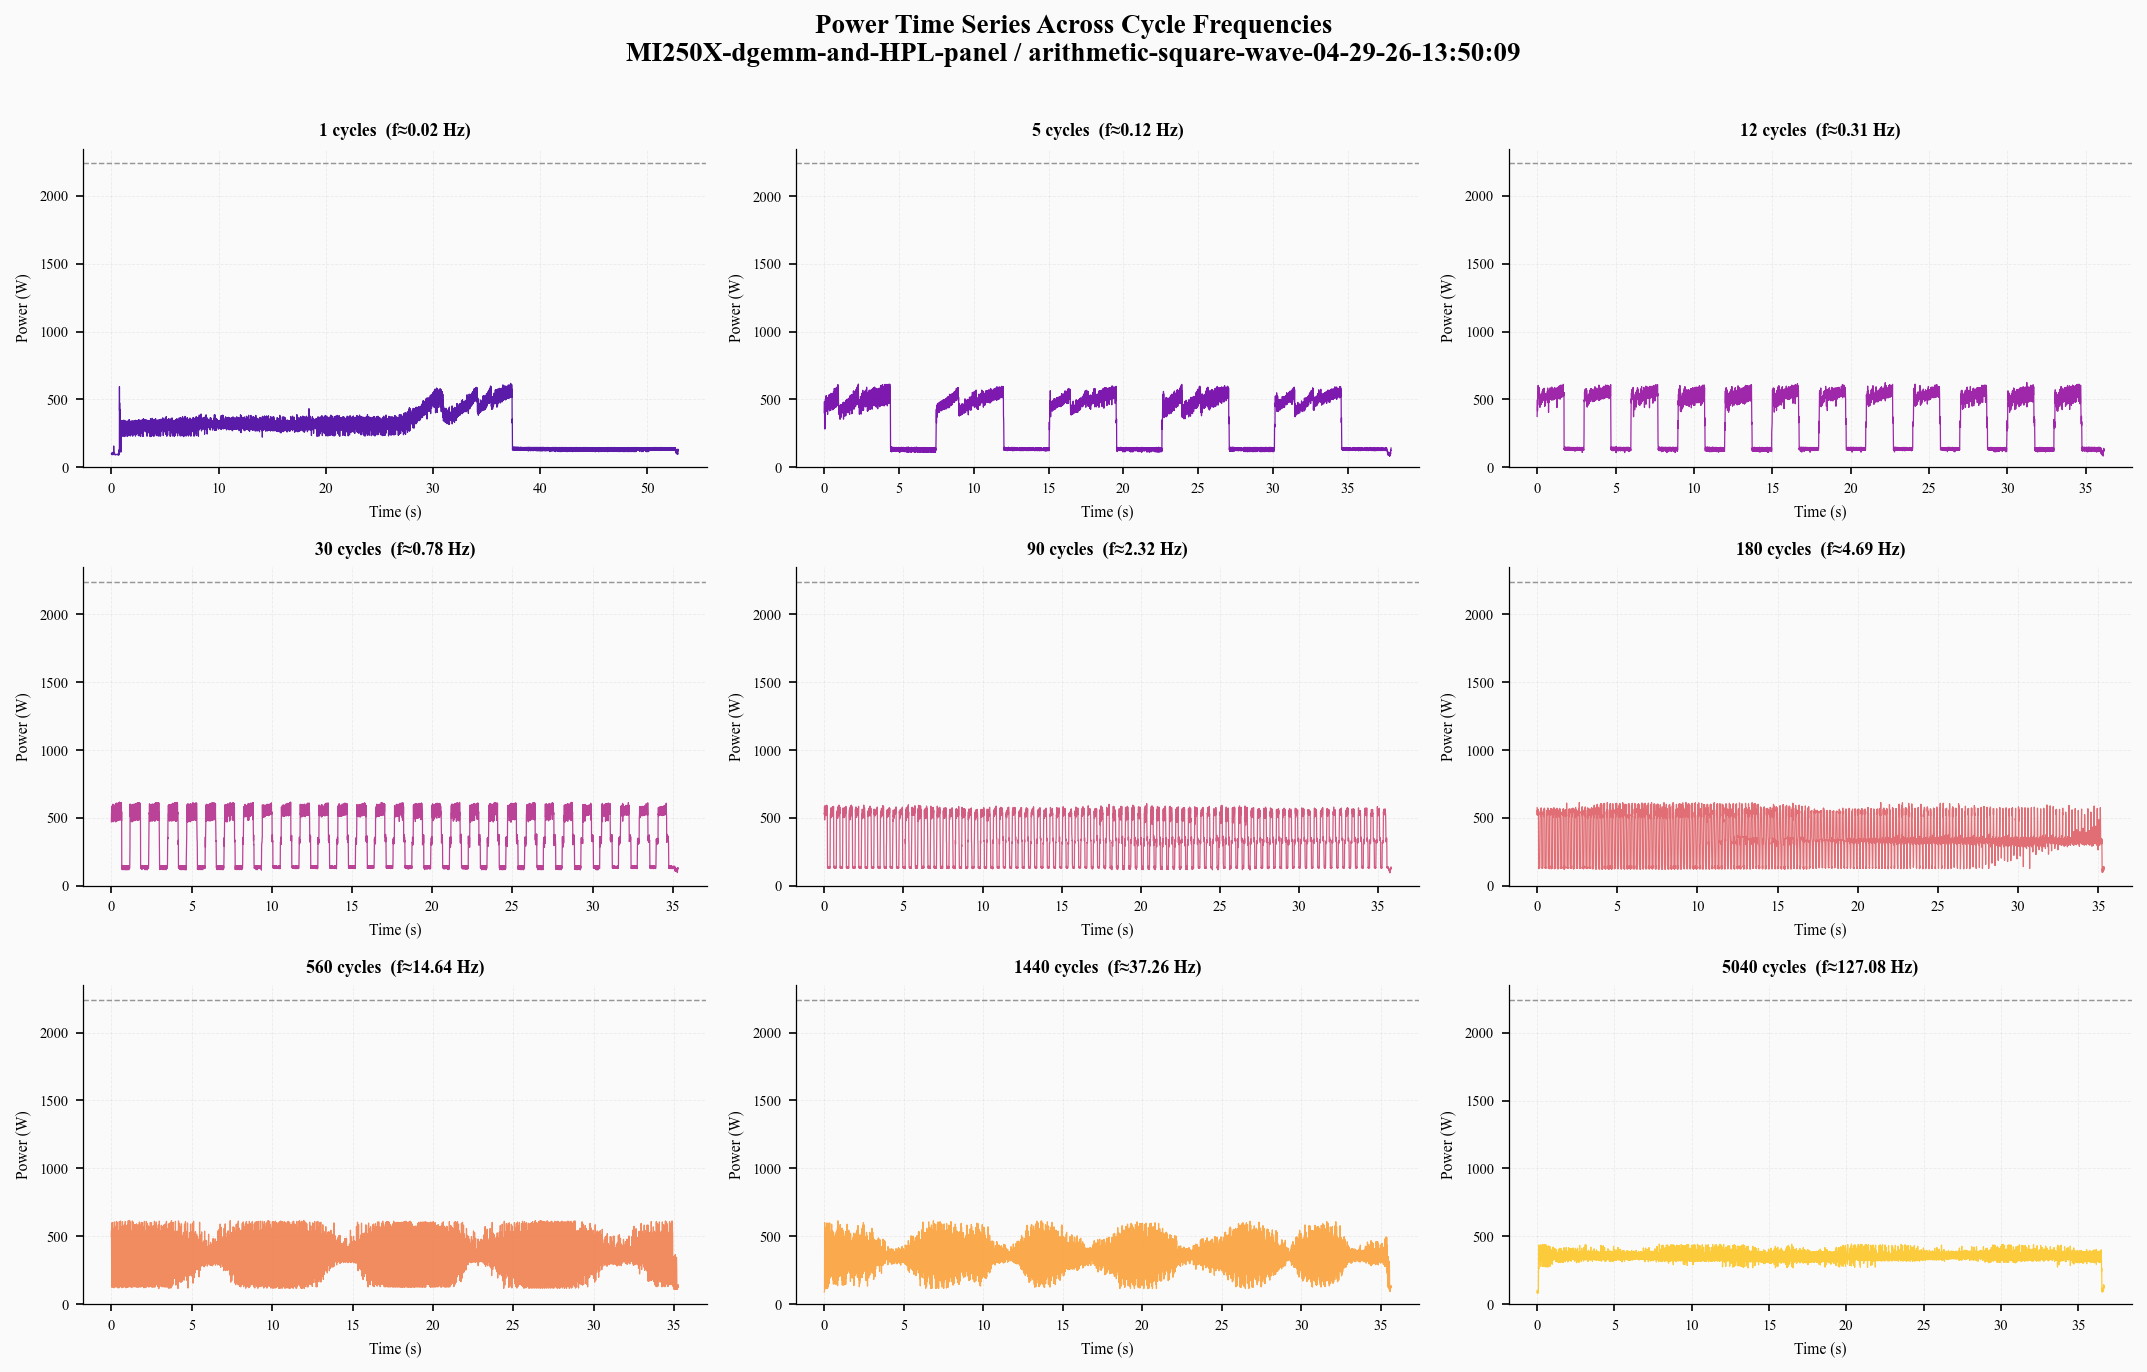

In [50]:
for exp_key, power_data in exp_power.items():
    if not power_data: continue
    cycle_counts = sorted(power_data.keys())
    n_total = len(cycle_counts)

    # Pick ~9 representative samples across the range
    idx_picks = np.unique(np.round(np.linspace(0, n_total - 1, min(9, n_total))).astype(int))
    picks = [cycle_counts[i] for i in idx_picks]

    ncols = 3
    nrows = int(np.ceil(len(picks) / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(ncols * 4.8, nrows * 3.0),
                              facecolor=BG)
    axes = np.array(axes).flatten()

    PALETTE = plt.cm.plasma(np.linspace(0.12, 0.88, n_total))
    color_of = {cc: PALETTE[i] for i, cc in enumerate(cycle_counts)}

    for ax_i, n_cyc in enumerate(picks):
        ax = axes[ax_i]
        ax.set_facecolor(BG)
        t, p = power_data[n_cyc]
        t_skip = 3.0
        mask = t >= t[0] + t_skip
        ax.plot(t[mask] - t[mask][0], p[mask],
                lw=0.6, color=color_of[n_cyc], alpha=0.9)
        ax.axhline(TDP_TOTAL, color='black', lw=0.7, ls='--', alpha=0.4)
        ax.set_title(f'{n_cyc} cycles  (f≈{f0_of(t, n_cyc):.2f} Hz)',
                     fontsize=8.5, fontweight='bold')
        ax.set_ylim(0)
        ax.set_xlabel('Time (s)', fontsize=7.5)
        ax.set_ylabel('Power (W)', fontsize=7.5)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.2, linestyle='--')

    for ax in axes[len(picks):]:
        ax.set_visible(False)

    fig.suptitle(f'Power Time Series Across Cycle Frequencies\n{exp_key}',
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    fig.savefig(f'fig1_sq_gallery_{exp_key.replace("/","_").replace(" ","")}.pdf',
                facecolor=BG, bbox_inches='tight')
    plt.show()


## Figure 2: Composite Bode Plot

For each run, compute the ratio of measured amplitude at f₀ to the ideal square-wave amplitude.  The resulting curve traces the **transfer function** of the GPU power system.

MI250X-dgemm-and-HPL-panel / arithmetic-square-wave-04-29-26-13:50:09:
  Estimated −3 dB bandwidth:  0.821 Hz
  Corresponding half-cycle:   609.1 ms
  Fitted corner frequency fc = 0.363 Hz
  Fitted time constant    τ  = 438.1 ms


/var/folders/tw/01tr8b7x7qx2w8074rmfk1qc0000gp/T/ipykernel_85821/4284070417.py:88: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Times New Roman.
  plt.tight_layout()
/var/folders/tw/01tr8b7x7qx2w8074rmfk1qc0000gp/T/ipykernel_85821/4284070417.py:89: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Times New Roman.
  fig.savefig(f'fig2_bode_{exp_key.replace("/","_").replace(" ","")}.pdf',
/Users/hom/miniconda3/envs/ampere_dev/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)


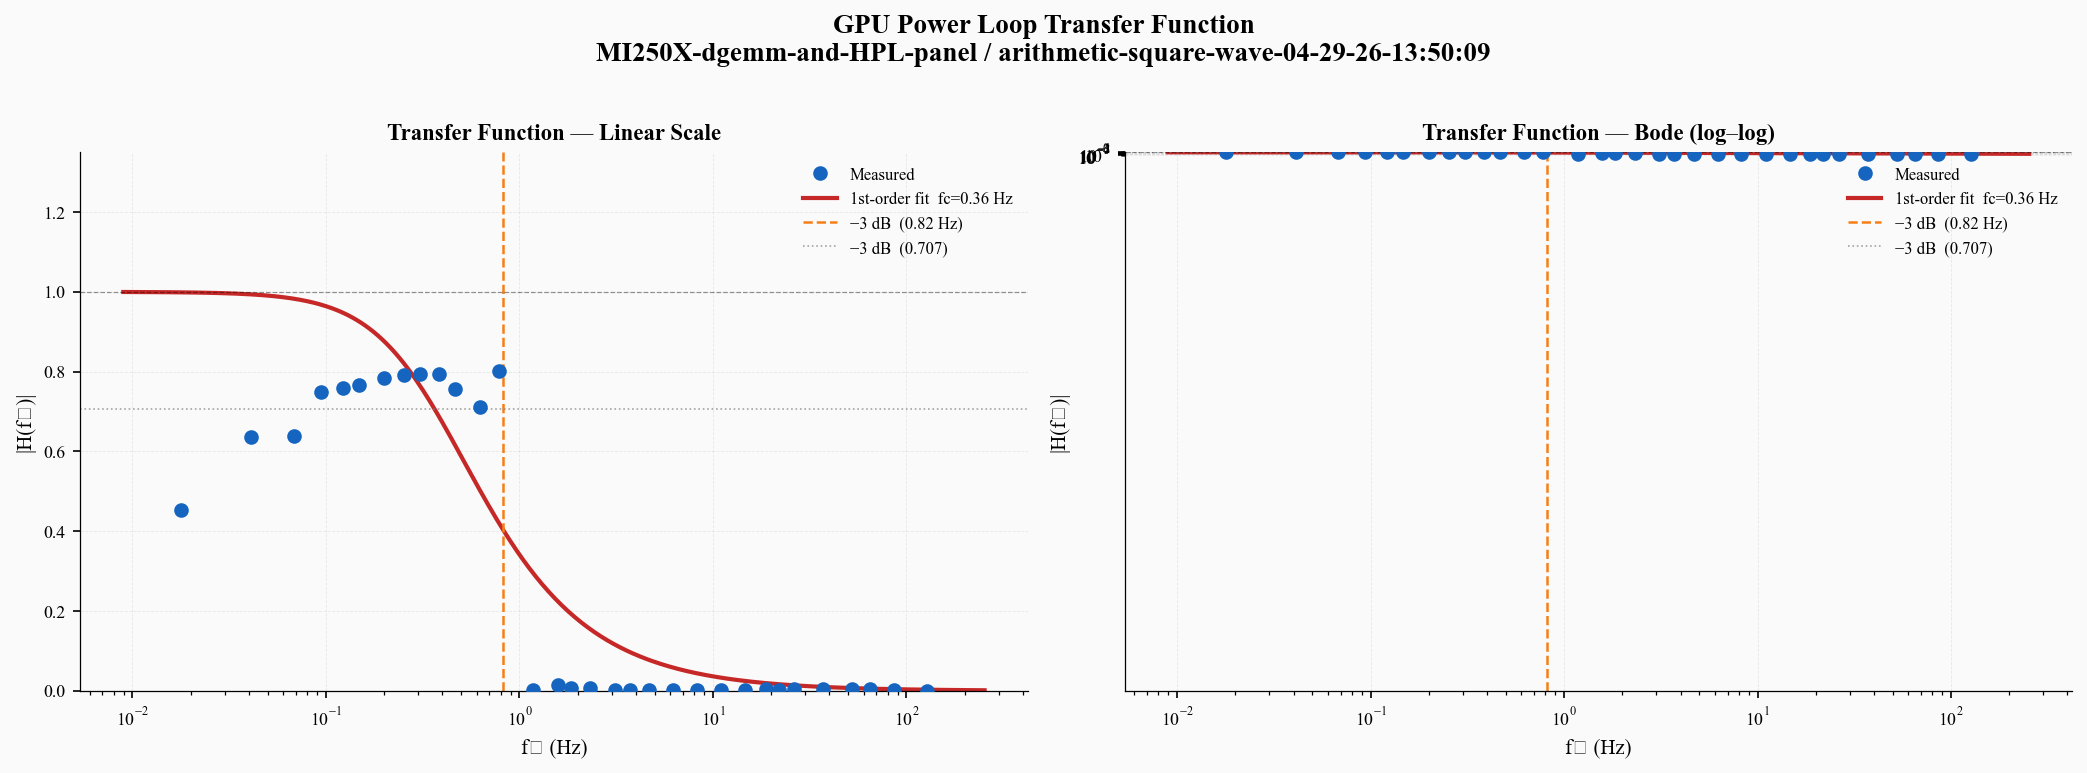

In [51]:
for exp_key, power_data in exp_power.items():
    if not power_data: continue
    cycle_counts_sorted = sorted(power_data.keys())

    tf_freq, tf_ratio, tf_amp_ideal, tf_amp_meas = [], [], [], []
    for n_cyc in cycle_counts_sorted:
        t, p = power_data[n_cyc]
        f0   = f0_of(t, n_cyc)
        fg, mg = amplitude_spectrum(t, p, fs_max=500.0, dt=0.001)
        A    = square_wave_amplitude(t, p)
        if not len(fg) or A <= 0:
            continue
        ideal_f0 = 4.0 * A / np.pi
        meas_f0  = measured_at(fg, mg, f0)
        ratio    = meas_f0 / ideal_f0 if ideal_f0 > 0 else np.nan
        tf_freq.append(f0);       tf_ratio.append(ratio)
        tf_amp_ideal.append(ideal_f0); tf_amp_meas.append(meas_f0)

    tf_freq  = np.array(tf_freq)
    tf_ratio = np.array(tf_ratio)
    sort_idx = np.argsort(tf_freq)
    tf_f_s   = tf_freq[sort_idx]
    tf_r_s   = tf_ratio[sort_idx]

    # --- Fit first-order LP ---
    valid = np.isfinite(tf_r_s) & (tf_r_s > 0)
    fc_fit = tau_fit = np.nan
    try:
        popt, _ = curve_fit(first_order_lp, tf_f_s[valid], tf_r_s[valid],
                            p0=[1.0], bounds=(0.01, 1000))
        fc_fit  = popt[0]
        tau_fit = 1.0 / (2 * np.pi * fc_fit)
    except RuntimeError:
        pass

    # --- −3 dB crossing ---
    target = 1.0 / np.sqrt(2)
    f3dB   = np.nan
    f_v, r_v = tf_f_s[valid], tf_r_s[valid]
    for k in range(len(r_v) - 1):
        if r_v[k] >= target > r_v[k + 1]:
            frac = (target - r_v[k]) / (r_v[k + 1] - r_v[k])
            f3dB = np.exp(np.log(f_v[k]) + frac * (np.log(f_v[k + 1]) - np.log(f_v[k])))
            break

    if np.isfinite(f3dB):
        print(f"{exp_key}:")
        print(f"  Estimated −3 dB bandwidth:  {f3dB:.3f} Hz")
        print(f"  Corresponding half-cycle:   {1000/(2*f3dB):.1f} ms")
    if np.isfinite(fc_fit):
        print(f"  Fitted corner frequency fc = {fc_fit:.3f} Hz")
        print(f"  Fitted time constant    τ  = {tau_fit*1000:.1f} ms")

    # --- Plot ---
    f_dense = np.logspace(np.log10(tf_f_s[valid].min()) - 0.3,
                          np.log10(tf_f_s[valid].max()) + 0.3, 400)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
    for ax in axes: ax.set_facecolor(BG)

    for ax, (xlabel, ylabel, use_log) in zip(
            axes,
            [('f₀ (Hz)', '|H(f₀)|', False),
             ('f₀ (Hz)', '|H(f₀)|', True)]):
        ax.semilogx(tf_f_s, tf_ratio, 'o', color='#1565C0', ms=6,
                    zorder=4, label='Measured')
        if np.isfinite(fc_fit):
            ax.semilogx(f_dense, first_order_lp(f_dense, fc_fit),
                        color='#C62828', lw=2,
                        label=f'1st-order fit  fc={fc_fit:.2f} Hz')
        if np.isfinite(f3dB):
            ax.axvline(f3dB, color='#F57F17', lw=1.2, ls='--',
                       label=f'−3 dB  ({f3dB:.2f} Hz)')
        ax.axhline(1/np.sqrt(2), color='grey', lw=0.8, ls=':', alpha=0.7,
                   label='−3 dB  (0.707)')
        ax.axhline(1.0, color='black', lw=0.6, ls='--', alpha=0.4)
        ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.set_ylim(0, 1.35)
        ax.legend(frameon=False, fontsize=8)
        ax.grid(alpha=0.25, linestyle='--')

    axes[0].set_title('Transfer Function — Linear Scale', fontweight='bold')
    axes[1].set_title('Transfer Function — Bode (log–log)', fontweight='bold')
    axes[1].set_yscale('log')

    fig.suptitle(f'GPU Power Loop Transfer Function\n{exp_key}',
                 fontweight='bold', y=1.02)
    plt.tight_layout()
    fig.savefig(f'fig2_bode_{exp_key.replace("/","_").replace(" ","")}.pdf',
                facecolor=BG, bbox_inches='tight')
    plt.show()


## Figure 3: Phase-Folded Cycle Shapes

For a selection of cycle counts, fold all cycles onto the unit interval [0, 1] and plot the average waveform.  At low frequency the envelope is a sharp square; at high frequency it becomes sinusoidal.

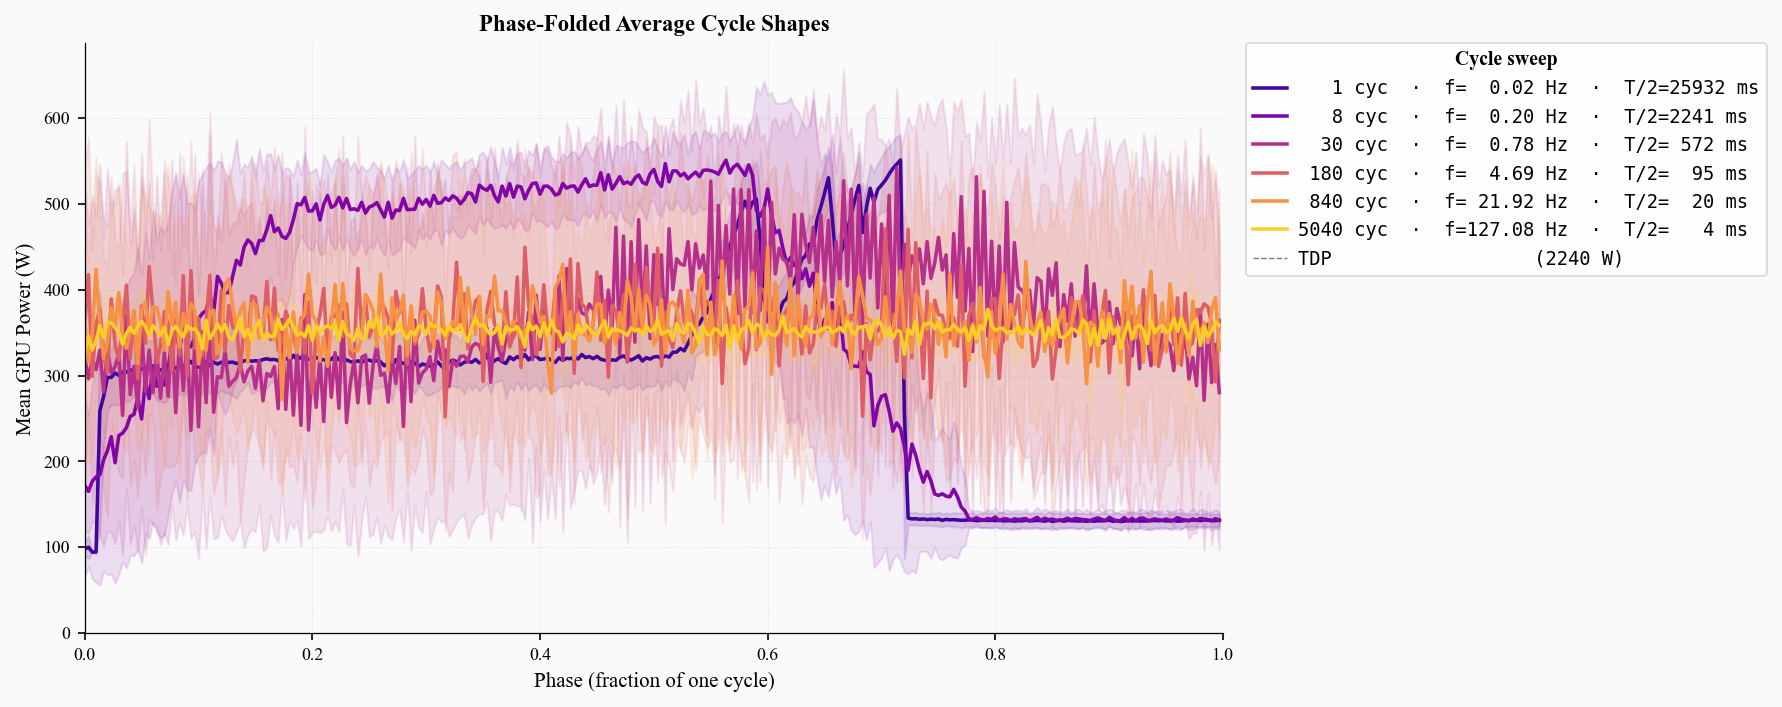

In [52]:
for exp_key, power_data in exp_power.items():
    if not power_data: continue
    cycle_counts_sorted = sorted(power_data.keys())
    n_total = len(cycle_counts_sorted)

    # Sample ~6 representative runs
    picks = [cycle_counts_sorted[i]
             for i in np.unique(np.round(
                 np.linspace(0, n_total-1, min(6, n_total))).astype(int))]
    PALETTE = plt.cm.plasma(np.linspace(0.10, 0.90, len(picks)))

    # Wider figure so the right-side legend has room without squashing the plot.
    fig, ax = plt.subplots(figsize=(12, 4.8), facecolor=BG)
    ax.set_facecolor(BG)

    for col, n_cyc in zip(PALETTE, picks):
        t, p = power_data[n_cyc]
        ph, mn, sd, period = fold_cycles(t, p, n_cyc)
        if ph is None: continue
        f0 = f0_of(t, n_cyc)
        # Monospace-aligned columns so the legend reads as a tidy table
        label = (f"{n_cyc:>4d} cyc  ·  "
                 f"f={f0:6.2f} Hz  ·  "
                 f"T/2={int(round(1000 * period / 2)):>4d} ms")
        ax.plot(ph, mn, lw=1.7, color=col, label=label)
        if sd is not None:
            ax.fill_between(ph, mn - sd, mn + sd, alpha=0.12, color=col)

    ax.set_xlabel('Phase (fraction of one cycle)')
    ax.set_ylabel('Mean GPU Power (W)')
    ax.set_title('Phase-Folded Average Cycle Shapes', fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_ylim(0)
    ax.axhline(TDP_TOTAL, color='black', lw=0.7, ls='--', alpha=0.5,
               label=f"TDP{' ' * 18}({TDP_TOTAL} W)")
    ax.grid(alpha=0.25, linestyle='--')

    # Legend outside the axes on the right, framed and monospaced for readability.
    leg = ax.legend(
        loc='upper left',
        bbox_to_anchor=(1.02, 1.0),
        frameon=True,
        facecolor='white',
        edgecolor='#dcdcdc',
        framealpha=0.95,
        handlelength=1.8,
        handletextpad=0.6,
        borderaxespad=0.0,
        prop={'family': 'monospace', 'size': 9},
        title='Cycle sweep',
        title_fontsize=9.5,
    )
    leg.get_title().set_fontweight('bold')

    fig.tight_layout()
    fig.savefig(f'fig3_phase_folded_{exp_key.replace("/","_").replace(" ","")}.pdf',
                facecolor=BG, bbox_inches='tight')
    plt.show()


## Figure 4: Amplitude Spectrum Heatmap

Display the full frequency content of every run as a 2-D heatmap: Y axis = cycle count (log), X axis = frequency, color = spectral power density.  The evolving harmonic structure shows how higher harmonics are progressively attenuated as cycle frequency rises.

/var/folders/tw/01tr8b7x7qx2w8074rmfk1qc0000gp/T/ipykernel_85821/2370915407.py:51: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Times New Roman.
  fig.tight_layout()
/var/folders/tw/01tr8b7x7qx2w8074rmfk1qc0000gp/T/ipykernel_85821/2370915407.py:52: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Times New Roman.
  fig.savefig(f'fig4_spectrum_heatmap_{exp_key.replace("/","_").replace(" ","")}.pdf',
/Users/hom/miniconda3/envs/ampere_dev/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Times New Roman.
  fig.canvas.print_figure(bytes_io, **kw)


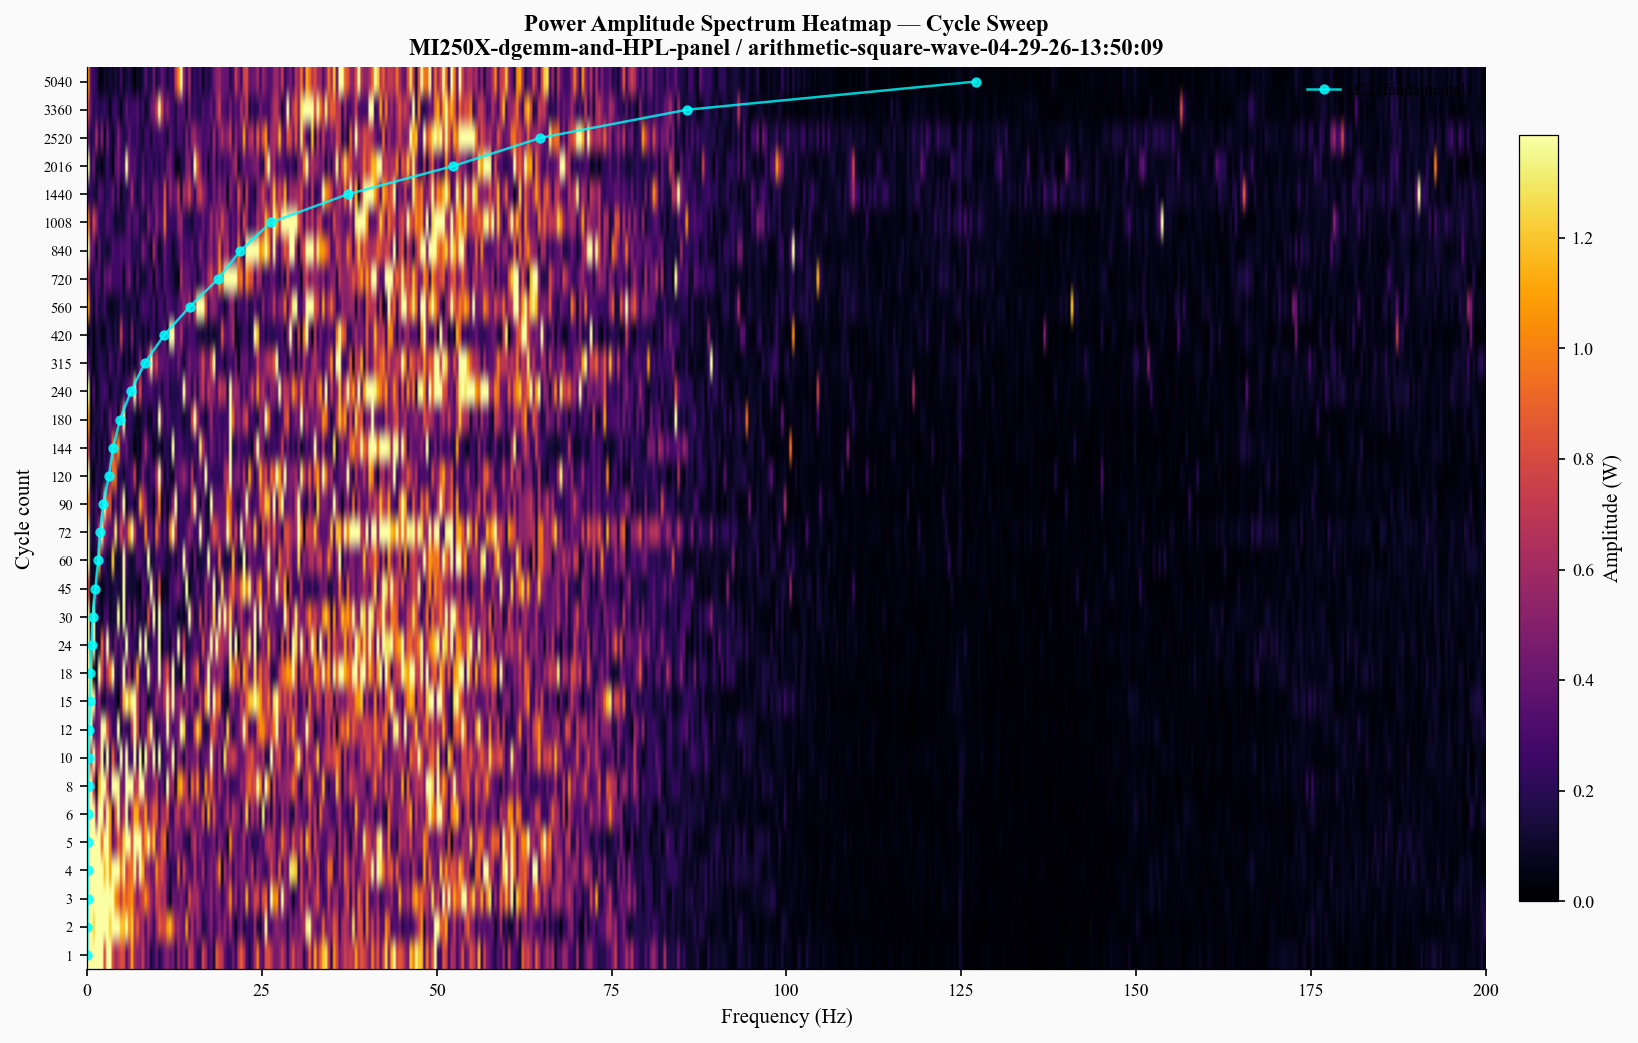

In [53]:
for exp_key, power_data in exp_power.items():
    if not power_data: continue
    cycle_counts_sorted = sorted(power_data.keys())

    # Build a common frequency grid
    freq_max_hz = 200.0
    n_freq_bins = 512
    freq_grid   = np.linspace(0, freq_max_hz, n_freq_bins)

    rows, valid_cc = [], []
    for n_cyc in cycle_counts_sorted:
        t, p = power_data[n_cyc]
        fg, mg = amplitude_spectrum(t, p, fs_max=freq_max_hz * 2, dt=0.001)
        if not len(fg): continue
        # Interpolate onto common grid
        row = np.interp(freq_grid, fg, mg, left=0, right=0)
        rows.append(row)
        valid_cc.append(n_cyc)

    if len(rows) < 2:
        print(f"  Not enough spectral data for {exp_key}")
        continue

    mat = np.array(rows)   # shape: (n_runs, n_freq_bins)

    # Mark fundamental frequency per run
    f0s = [cycle_count / (power_data[cc][0][-1] - power_data[cc][0][0])
           for cc, cycle_count in zip(valid_cc, valid_cc)]

    fig, ax = plt.subplots(figsize=(12, max(4, 0.22 * len(valid_cc))), facecolor=BG)
    ax.set_facecolor(BG)

    vmax = np.percentile(mat, 97)
    im = ax.imshow(mat, aspect='auto', origin='lower',
                   extent=[freq_grid[0], freq_grid[-1], 0, len(valid_cc)],
                   cmap='inferno', vmin=0, vmax=vmax)
    plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02, label='Amplitude (W)')

    # Overlay fundamental frequency trajectory
    ax.plot(f0s, np.arange(len(valid_cc)) + 0.5, '-o', color='cyan',
            lw=1.2, ms=4, alpha=0.8, label='f₀ (fundamental)')

    ax.set_yticks(np.arange(len(valid_cc)) + 0.5)
    ax.set_yticklabels(valid_cc, fontsize=7)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Cycle count')
    ax.set_title(f'Power Amplitude Spectrum Heatmap — Cycle Sweep\n{exp_key}',
                 fontweight='bold')
    ax.legend(frameon=False, fontsize=8, loc='upper right')

    fig.tight_layout()
    fig.savefig(f'fig4_spectrum_heatmap_{exp_key.replace("/","_").replace(" ","")}.pdf',
                facecolor=BG, bbox_inches='tight')
    plt.show()


## Figure 5: Per-Device Power vs. Half-Cycle Length

Show mean power per physical GPU device across the full frequency sweep.  Reveals any inter-device asymmetries in how power responds to cycle frequency.

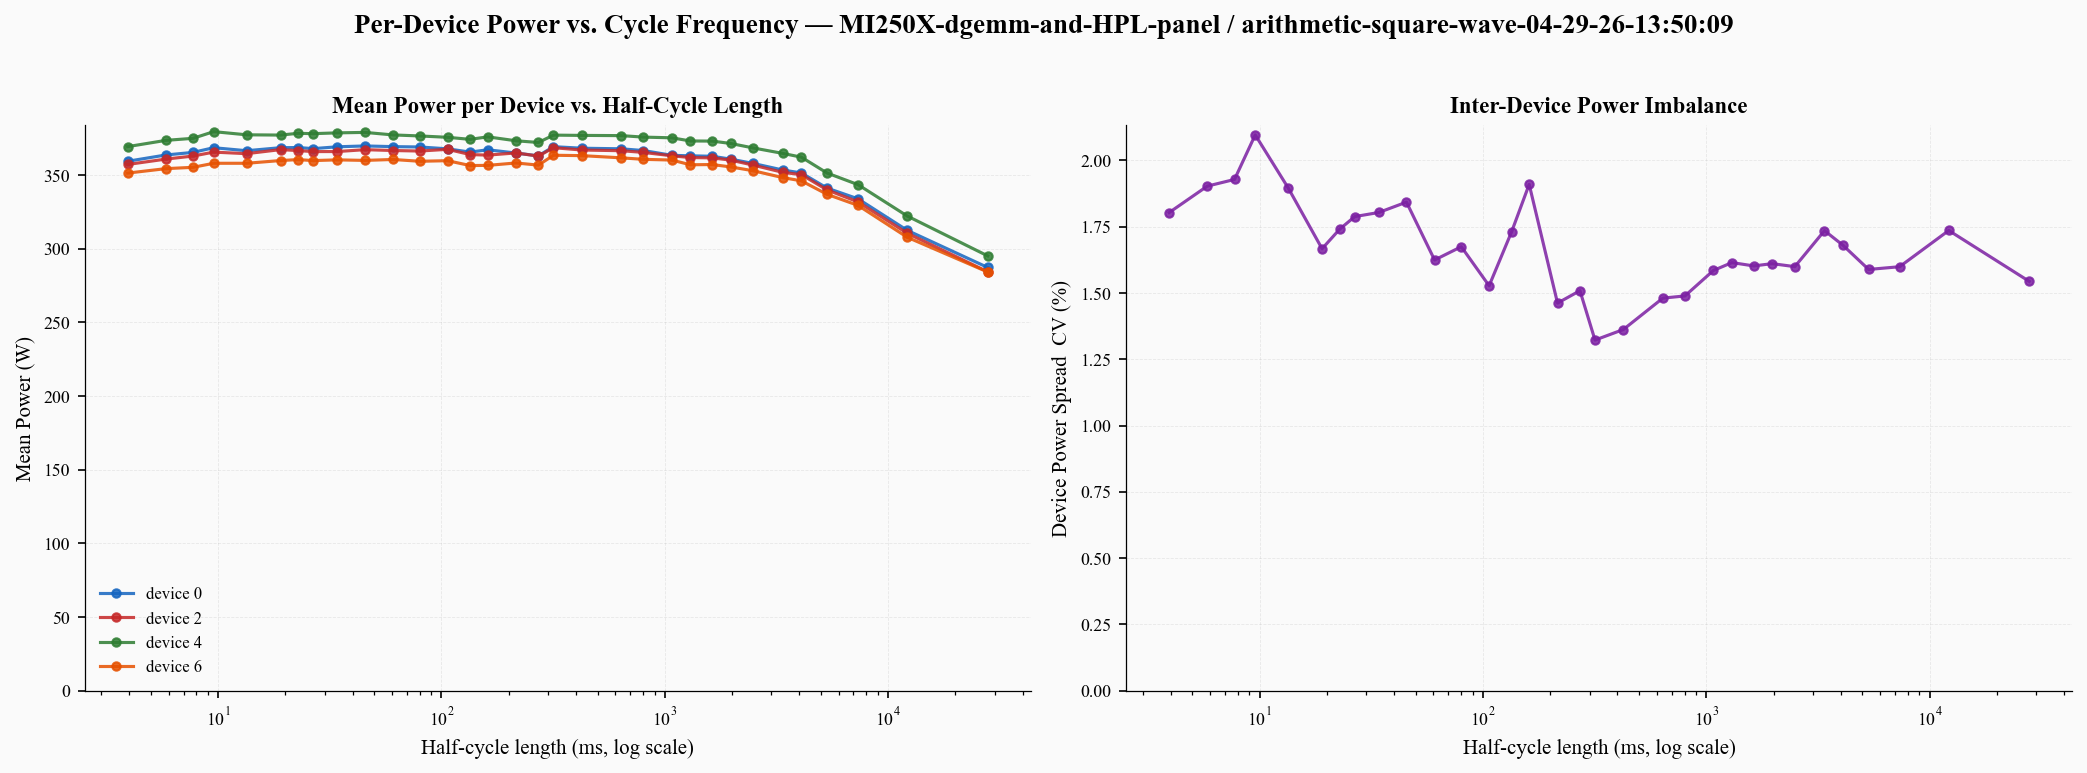

In [54]:
for exp_key, info in SW_EXPERIMENTS.items():
    power_data = exp_power.get(exp_key, {})
    if not power_data: continue

    # Load per-device power from CSV (no server needed for this figure)
    cycle_counts_sorted = sorted(power_data.keys())
    half_ms_arr = np.array([half_period_ms(power_data[cc][0], cc)
                             for cc in cycle_counts_sorted])
    order = np.argsort(half_ms_arr)
    half_ms_sorted = half_ms_arr[order]
    cc_sorted = [cycle_counts_sorted[i] for i in order]

    # Per-device mean power from the combined Ensemble already loaded
    # Re-derive from raw metrics CSVs for per-device breakdown
    device_means = {d: [] for d in GPU_DEVICES}

    for cc in cc_sorted:
        # Find the matching cycles directory
        cycles_dir = info['exp_dir'] / f"cycles-{cc}"
        m_path = cycles_dir / "Process_metrics.csv"
        if not m_path.exists():
            for d in GPU_DEVICES: device_means[d].append(np.nan)
            continue
        dm = pd.read_csv(m_path)
        for dev in GPU_DEVICES:
            sub = dm[dm['Metric Name'] == f'A2rocm_smi:::energy_count:device={dev}'].sort_values('Time')
            if len(sub) < 2:
                device_means[dev].append(np.nan)
                continue
            t = sub['Time'].values; e = sub['Value'].values * 1e-6
            dt = np.diff(t); de = np.diff(e)
            p  = np.where((dt > 0) & (de >= 0), de / dt, 0.0)
            t_skip = 3.0
            mask = t[1:] >= t[1] + t_skip
            device_means[dev].append(float(np.nanmean(p[mask])) if mask.any() else np.nan)

    # Coefficient of variation across devices
    dm_arr = np.array([device_means[d] for d in GPU_DEVICES])  # 4 x N
    cv     = np.nanstd(dm_arr, axis=0) / np.nanmean(dm_arr, axis=0)

    DCOLORS = {0: '#1565C0', 2: '#C62828', 4: '#2E7D32', 6: '#E65100'}

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
    for ax in axes: ax.set_facecolor(BG)

    # Left: mean power per device
    for dev in GPU_DEVICES:
        vals = np.array(device_means[dev])
        axes[0].semilogx(half_ms_sorted, vals, '-o', lw=1.5, ms=4,
                         color=DCOLORS[dev], label=f'device {dev}', alpha=0.85)
    axes[0].set_xlabel('Half-cycle length (ms, log scale)')
    axes[0].set_ylabel('Mean Power (W)')
    axes[0].set_title('Mean Power per Device vs. Half-Cycle Length', fontweight='bold')
    axes[0].legend(frameon=False, fontsize=8)
    axes[0].grid(alpha=0.25, linestyle='--')
    axes[0].set_ylim(0)

    # Right: coefficient of variation
    axes[1].semilogx(half_ms_sorted, cv * 100, '-o', color='#7B1FA2',
                     lw=1.5, ms=4, alpha=0.85)
    axes[1].set_xlabel('Half-cycle length (ms, log scale)')
    axes[1].set_ylabel('Device Power Spread  CV (%)')
    axes[1].set_title('Inter-Device Power Imbalance', fontweight='bold')
    axes[1].set_ylim(0)
    axes[1].grid(alpha=0.25, linestyle='--')

    fig.suptitle(f'Per-Device Power vs. Cycle Frequency — {exp_key}',
                 fontweight='bold', y=1.02)
    plt.tight_layout()
    fig.savefig(f'fig5_device_power_{exp_key.replace("/","_").replace(" ","")}.pdf',
                facecolor=BG, bbox_inches='tight')
    plt.show()
